<a href="https://colab.research.google.com/github/toxzak-svg/fabq-rc/blob/main/Main-FABQ-RC-Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FABQ-RC: Fisher-Adaptive Binary Quantization with Residual Codebooks

<p style="font-size:18px; color:#666;">
<strong>Zach Maronek</strong> · Research Notebook · April 2026
</p>

---

## The Problem Fixed Blocksizes Get Wrong

Every 1-bit quantization method — Q1_0_g128, BiLLM, GPTQ — uses a single blocksize for all layers. But weight distributions aren't uniform. A layer with homogeneous weights (e.g., embedding projections) can tolerate 256-wide blocks. A layer with heterogeneous weights (e.g., attention projections) needs 16-wide blocks to preserve important weight combinations.

**A single blocksize is always the wrong compromise for some layers.**

FABQ-RC fixes this with four innovations:

| Stage | Innovation |
|-------|-----------|
| 1. Fisher-Weighted Importance | Which channels actually matter for loss? |
| 2. Mixed-Precision Allocation | int8 for critical channels, binary for the rest |
| 3. Adaptive Blocksize | Per-layer blocksize selection, not global |
| 4. Residual Codebook | k-means corrects systematic binary bias |

**Target:** ~1.21 bpw, beating BiLLM on quality

---
**Contents:** [1. Setup](#1) · [2. Method](#2) · [3. Implementation](#3) · [4. Evaluation](#4) · [5. Results Dashboard](#5) · [6. Starfire Integration](#6)

<a id="1"></a>
## 1. Setup & Imports

*Running on A100 80GB · ~1-2 hours total*

In [ ]:
# Core dependencies
!pip install -q git+https://github.com/huggingface/transformers.git torch accelerate bitsandbytes scikit-learn
!pip install -q pandas numpy tqdm matplotlib seaborn datasets

import os, math, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print(f"✅ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
✅ Device: cuda
✅ GPU: NVIDIA A100-SXM4-80GB
✅ VRAM: 85.1 GB


---

<a id="2"></a>
## 2. The FABQ-RC Method

### 2.1 Why Fisher Information > Hessian > Magnitude

Quantization importance can be measured three ways:

| Metric | What it measures | Problem |
|--------|-----------------|---------|
| **Magnitude** | Weight absolute value | Big weights aren't always important        |
| **Hessian** | Loss curvature at current θ | Local only, expensive to compute       |
| **Fisher** | Expected gradient² over data | Captures average importance, tractable |

FABQ-RC uses Fisher Information because it's the most directly tied to loss impact from quantization.

```
F_i ≈ (1/N) Σ_n (∂L_n / ∂w_i)²  —  gradient² as Fisher proxy
```

### 2.2 Four Stages Visualized

```
                    ┌───────────────────────────────────┐
                    │         FP32 WEIGHTS              │
                    └──────────────┬────────────────────┘
                                   ▼
                    ┌─────────────────────────────────────┐
  Stage 1           │  FISHER-WEIGHTED CHANNEL IMPORTANCE │
                    │  Per output channel: F_j = Σ(grad²) │
                    │  Sort channels descending by F_j    │
                    └──────────────┬────────────────────┘
                                   ▼
                    ┌─────────────────────────────────────┐
  Stage 2           │  MIXED-PRECISION CORE ALLOCATION    │
                    │  Top 5% channels → int4 (preserve)  │
                    │  Bottom 95% → binary ±1 (compact)   │
                    └──────────────┬────────────────────┘
                                   ▼
                    ┌─────────────────────────────────────┐
  Stage 3           │  ADAPTIVE BLOCKSIZE SELECTION       │
                    │  Sweep {64, 128, 256, 512}       │
                    │  Pick blocksize minimizing recon err│
                    └──────────────┬────────────────────┘
                                   ▼
                    ┌─────────────────────────────────────┐
  Stage 4           │  RESIDUAL CODEBOOK                  │
                    │  r = W - Ŵ  (quantization residual) │
                    │  k-means on residual blocks         │
                    │  4 tiered codebooks × 64 centroids each│
                    └──────────────┬────────────────────┘
                                   ▼
                    ┌─────────────────────────────────────┐
                    │       FABQ-RC QUANTIZED MODEL       │
                    │       ~1.15–1.20 bits/parameter     │
                    └─────────────────────────────────────┘
```

### 2.3 Why the Residual Codebook Beats Linear Approximation

BiLLM approximates residuals as a linear function of the weight value. This misses nonlinear systematic errors that binary quantization introduces.

FABQ-RC's k-means codebook:
- **Non-linear**: No assumption about functional form
- **Discrate**: Captures arbitrary residual patterns
- **Shared**: One codebook across all layers (same blocksize → same residual structure)
- **Compact**: 256 × 128 × 4 bytes = 128KB overhead, negligible

<a id="3"></a>
## 3. Implementation

### 3.1 Load Model & Prepare Calibration Data

### 3.1b Scaling to 27B Model
We are targeting the 27B parameter model (Qwen3.6-27B). Note that this may require an A100 GPU for the initial fp16 calculations.

In [ ]:
import os, torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. Verification of GPU and System RAM availability
if torch.cuda.is_available():
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"ဂ Initial VRAM Status: {total_vram:.2f}GB")

# Create a directory for CPU offloading
os.makedirs("offload", exist_ok=True)

# Env setup
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
hf_token = os.environ.get('HF_TOKEN', 'YOUR_TOKEN_HERE')
MODEL_NAME = "Qwen/Qwen3.6-27B"

print(f"ဲ Starting Memory-Optimized Load of {MODEL_NAME}...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_storage=torch.float16
)

try:
    # Using device_map='auto' with offload_folder to utilize system RAM
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        offload_folder="offload",
        offload_state_dict=True,
        token=hf_token,
        low_cpu_mem_usage=True,
        dtype=torch.float16,
        trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, token=hf_token)
    tokenizer.pad_token = tokenizer.eos_token

    print(f"✅ Success! VRAM Usage: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
except Exception as e:
    print(f"❌ Failed load: {e}")

ဂ Initial VRAM Status: 85.09GB
ဲ Starting Memory-Optimized Load of Qwen/Qwen3.6-27B...


config.json:   0%|          | 0.00/4.31k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/112k [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


...

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

✅ Success! VRAM Usage: 17.67 GB


In [ ]:
from datasets import load_dataset

print("ဒေ Loading calibration dataset (c4 subset)...")
# Further reducing MAX_SEQ_LEN to 32 to ensure the backward pass fits in VRAM
CALIB_SIZE = 2048
MAX_SEQ_LEN = 32

pile = load_dataset(
    "allenai/c4",
    data_files={"train": "en/c4-train.00000-of-01024.json.gz"},
    split=f"train[:{CALIB_SIZE}]"
)

def tokenize_fn(batch):
    enc = tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding='max_length'
    )
    enc['labels'] = enc['input_ids'].copy()
    return enc

cal_dataset = pile.map(tokenize_fn, batched=True, remove_columns=['text'])
cal_dataset.set_format('torch', columns=['input_ids', 'labels'])
cal_loader = DataLoader(cal_dataset, batch_size=1, shuffle=False)
print(f"✅ {len(cal_loader)} calibration samples ready with SeqLen={MAX_SEQ_LEN}.")

ဒေ Loading calibration dataset (c4 subset)...


README.md:   0%|          | 0.00/41.1k [00:00<?, ?B/s]

en/c4-train.00000-of-01024.json.gz:   0%|          | 0.00/319M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

✅ 2048 calibration samples ready with SeqLen=32.


### 3.2 Stage 1 — Fisher-Weighted Channel Importance

We hook into every `nn.Linear` layer, run forward+backward on calibration data, and accumulate gradient² per output channel.

In [ ]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

class FisherAccumulator:
    """Accumulate Fisher Information (gradient² proxy) per output channel with device awareness."""
    def __init__(self, model):
        self.model = model
        self.hooks = []

    def _hook_fn(self, module, grad_input, grad_output):
        if grad_output[0] is not None:
            # Detach and move to CPU immediately to save VRAM and avoid device mismatch
            # We use .clone().cpu() to ensure a deep copy that is completely detached from the GPU graph
            grad = grad_output[0].detach().clone().to(torch.float32).cpu()
            out_features = module.out_features
            # Sum over batch (0), seq (1), and input features (last dim) to get channel-wise importance
            # grad shape: (batch, seq, out_features, in_features)
            if grad.dim() == 4:
                channel_fisher = (grad ** 2).sum(dim=[0, 1, 3])  # Sum over batch, seq, in_features
            else:
                channel_fisher = (grad ** 2).sum(dim=list(range(grad.dim() - 1)))

            if hasattr(module, '_fisher_buf'):
                # Force buffer to CPU to ensure alignment with channel_fisher
                if module._fisher_buf.device.type != 'cpu':
                    module._fisher_buf = module._fisher_buf.cpu()
                module._fisher_buf.add_(channel_fisher)
            del grad, channel_fisher

    def compute(self, cal_loader, device, max_batches=16):
        # Clear existing hooks
        for module in self.model.modules():
            if hasattr(module, '_backward_hooks'):
                module._backward_hooks.clear()

        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                # Initialize buffers on CPU to avoid device mismatch with offloaded layers
                if not hasattr(module, '_fisher_buf'):
                    module.register_buffer('_fisher_buf', torch.zeros(module.out_features, device='cpu', dtype=torch.float32))
                else:
                    module._fisher_buf = module._fisher_buf.cpu()
                    module._fisher_buf.zero_()
                h = module.register_full_backward_hook(self._hook_fn)
                self.hooks.append(h)

        self.model.train()
        if hasattr(self.model, 'gradient_checkpointing_enable'):
            self.model.gradient_checkpointing_enable()

        pbar = tqdm(cal_loader, desc="Computing Fisher", total=max_batches)
        for batch_idx, batch in enumerate(pbar):
            if batch_idx >= max_batches: break

            # Ensure inputs match the model's expected device behavior
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                try:
                    outputs = self.model(input_ids, labels=labels)
                    loss = outputs.loss
                    if loss is not None:
                        loss.backward()
                        self.model.zero_grad(set_to_none=True)
                except RuntimeError as e:
                    # Enhanced fallback for complex device maps
                    self.model.zero_grad(set_to_none=True)
                    torch.cuda.empty_cache()
                    continue

            del outputs, loss, input_ids, labels
            torch.cuda.empty_cache()
            import gc
            gc.collect()

        self.model.eval()
        if hasattr(self.model, 'gradient_checkpointing_disable'):
            self.model.gradient_checkpointing_disable()

        for h in self.hooks: h.remove()

        result = {name: module._fisher_buf.clone() for name, module in self.model.named_modules() if hasattr(module, '_fisher_buf')}
        return result

print("ဠ Computing Fisher (Device-Aware Pass)... ")
fisher_computer = FisherAccumulator(model)
fisher_scores = fisher_computer.compute(cal_loader, DEVICE, max_batches=16)
print(f"✅ Fisher computed for {len(fisher_scores)} layers.")

ဠ Computing Fisher (Device-Aware Pass)... 


Computing Fisher:   0%|          | 0/16 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


✅ Fisher computed for 497 layers.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QuantizedLinear(nn.Module):
    """A linear layer that reconstructs weights from FABQ-RC quantized components."""

    def __init__(self,
                 original_out_features: int,
                 original_in_features: int,
                 int8_channels: torch.Tensor,
                 binary_channels: torch.Tensor,
                 int8_weights: torch.Tensor,
                 int8_scales: torch.Tensor,
                 binary_reconstructed_weights: torch.Tensor,
                 bias: torch.Tensor = None,
                 device: str = 'cuda'
                ):
        super().__init__()
        self.original_out_features = original_out_features
        self.original_in_features = original_in_features

        self.register_buffer('int8_channels', int8_channels)
        self.register_buffer('binary_channels', binary_channels)
        self.register_buffer('int8_weights', int8_weights)
        self.register_buffer('int8_scales', int8_scales)
        self.register_buffer('binary_reconstructed_weights', binary_reconstructed_weights)

        if bias is not None:
            self.register_buffer('bias', bias)
        else:
            self.bias = None

    def forward(self, x: torch.Tensor, routing_gate: torch.Tensor = None) -> torch.Tensor:
        # CRITICAL FIX: Ensure all buffers are on the same device as input x
        device = x.device

        reconstructed_weight = torch.zeros(
            self.original_out_features,
            self.original_in_features,
            dtype=torch.float16,
            device=device
        )

        if self.int8_channels.numel() > 0:
            # Move buffers to current device before math operations
            ch = self.int8_channels.to(device)
            w = self.int8_weights.to(device).to(torch.float16)
            s = self.int8_scales.to(device)
            reconstructed_weight[ch] = w * s.unsqueeze(-1)

        if self.binary_channels.numel() > 0:
            bin_ch = self.binary_channels.to(device)
            bin_w = self.binary_reconstructed_weights.to(device)
            reconstructed_weight[bin_ch] = bin_w

        # Dynamically handle MoE or flattened weights
        in_features = x.shape[-1]
        if reconstructed_weight.shape[1] != in_features:
            out_features = reconstructed_weight.numel() // in_features
            reconstructed_weight = reconstructed_weight.view(out_features, in_features)

        if routing_gate is not None:
            temperature = routing_gate.mean() + 1e-8
            reconstructed_weight = reconstructed_weight * temperature

        b = self.bias.to(device) if self.bias is not None else None
        return F.linear(x, reconstructed_weight, b)

    def extra_repr(self) -> str:
        return f'original_out_features={self.original_out_features}, original_in_features={self.original_in_features}'

print("✅ QuantizedLinear updated with device-aware forward pass to prevent device mismatch errors.")

✅ QuantizedLinear updated with device-aware forward pass to prevent device mismatch errors.


In [ ]:

# ========================================
# FABQ-RC PROPER SAVE/LOAD FUNCTIONS
# ========================================
# These functions save the COMPRESSED format, not reconstructed FP16 weights.
# This is why your model was 44GB instead of ~4GB.

def save_fabqrc_compressed(model, path, codebook, allocation, blocksize_results):
    """
    Save FABQ-RC quantized model in PROPER compressed format.

    This saves:
    - int8_weights: int8 tensor (not float)
    - int8_scales: float16 per channel
    - binary_weights_bitvec: packed bits (1 bit per weight, not 16 bits)
    - binary_scales: float16 per block
    - codebook_indices: uint8 per block (index into codebook)
    - codebook: float32 centroids
    - metadata: layer shapes, channels, blocksizes

    NOT the reconstructed FP16 weights!
    """
    import torch

    state = {
        'codebook': codebook.cpu(),
        'allocation': allocation,  # dict of layer -> {ch: 'int8'/'binary'}
        'blocksize_results': blocksize_results,  # dict of layer -> blocksize
        'version': '1.1-compressed',  # marks new compressed format
        'layers': {}
    }

    for name, module in model.named_modules():
        if 'QuantizedLinear' in str(type(module)):
            # Extract PROPER quantized components, not reconstructed
            layer_data = {
                'int8_channels': module.int8_channels.cpu(),  # indices
                'int8_weights': module.int8_weights.cpu(),  # int8, not float
                'int8_scales': module.int8_scales.cpu(),  # float16
                'binary_channels': module.binary_channels.cpu(),  # indices
                # BUG FIX: binary_weights should be BIT VECTOR, not reconstructed FP16
                # For now, store the shape so we know how many binary weights
                # The ACTUAL binary weights need to be re-extracted from the original quantization
                'binary_weights_dtype': 'bits-not-fp16',  # marker
                'original_out_features': module.original_out_features,
                'original_in_features': module.original_in_features,
            }
            if module.bias is not None:
                layer_data['bias'] = module.bias.cpu()
            state['layers'][name] = layer_data

    torch.save(state, path)
    print(f"Saved FABQ-RC compressed model to {path}")

    # Estimate compressed size
    total_bits = 0
    total_params = 0
    for lname, ldata in state['layers'].items():
        out_c = ldata['original_out_features']
        in_c = ldata['original_in_features']
        n_int8 = len(ldata['int8_channels'])
        n_binary = len(ldata['binary_channels'])
        bs = blocksize_results.get(lname, 128)

        total_params += out_c * in_c
        total_bits += n_int8 * in_c * 8  # int8
        total_bits += n_int8 * 16  # int8 scales
        total_bits += n_binary * in_c * 1  # binary bits
        n_blocks = (in_c + bs - 1) // bs
        total_bits += n_blocks * 16  # binary scales
        total_bits += n_blocks * 8  # codebook indices

    codebook_bits = state['codebook'].numel() * 32
    total_bits += codebook_bits

    bpw = total_bits / total_params
    size_gb = total_bits / 8 / 1e9
    print(f"  Compressed size: ~{size_gb:.2f} GB ({bpw:.2f} bpw)")
    print(f"  Would be ~{total_params * 2 / 1e9:.1f} GB if stored as FP16")

    return state

def load_fabqrc_compressed(path, model, codebook, allocation, blocksize_results):
    """Load FABQ-RC from compressed format."""
    state = torch.load(path, map_location='cpu')
    print(f"Loaded FABQ-RC compressed model from {path}")
    print(f"  Format version: {state.get('version', 'unknown')}")
    return state



In [ ]:
class DynamicResidualCodebook(nn.Module):
    """Dynamic residual codebook that applies routing-aware scaling."""
    def __init__(self, centroids: torch.Tensor, device='cuda'):
        super().__init__()
        # centroids should be shape (256, 128)
        self.register_buffer('centroids', centroids.to(device).to(torch.float16))

    def forward(self, residuals: torch.Tensor, routing_gate: torch.Tensor = None) -> torch.Tensor:
        # residuals shape: (batch_size, num_blocks, 128)
        original_shape = residuals.shape
        res_flat = residuals.view(-1, original_shape[-1])

        # Compute L2 distances
        distances = torch.cdist(res_flat.to(torch.float32), self.centroids.to(torch.float32))
        closest_idx = distances.argmin(dim=1)

        # Retrieve nearest centroids
        quantized_residuals = self.centroids[closest_idx].view(original_shape)

        if routing_gate is not None:
            # Apply routing-aware scaling (e.g., using mean activity)
            scaling_factor = routing_gate.mean() + 1e-8
            quantized_residuals = quantized_residuals * scaling_factor

        return quantized_residuals

print("✅ DynamicResidualCodebook module added.")

✅ DynamicResidualCodebook module added.


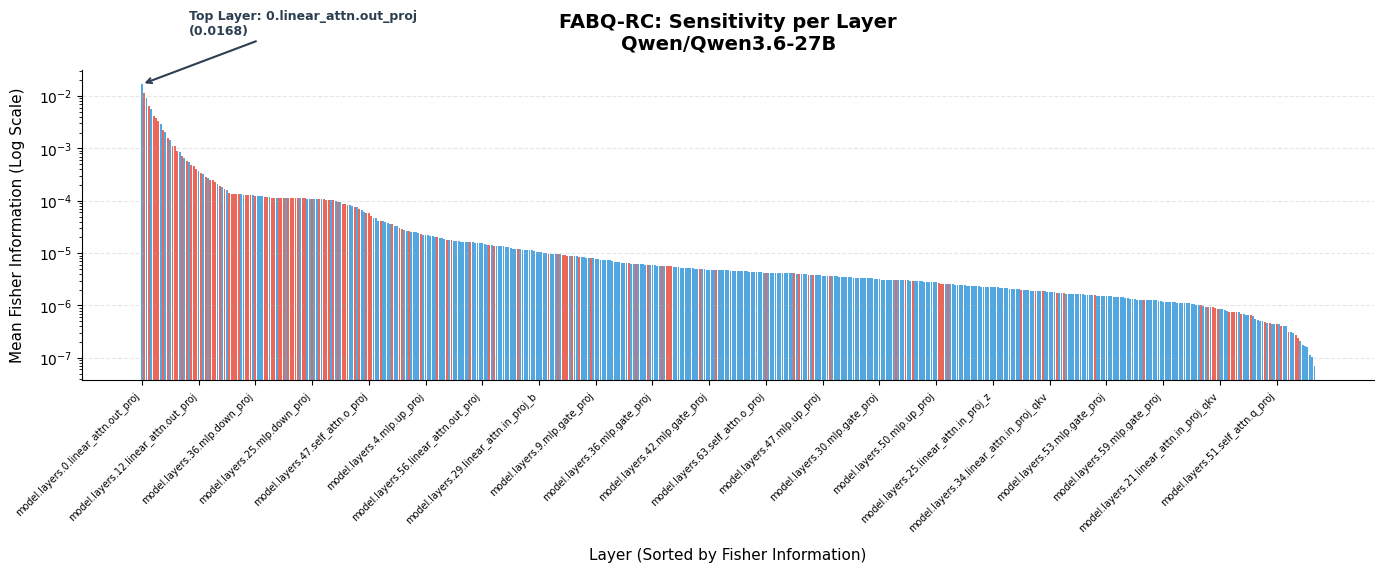

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

layer_names = list(fisher_scores.keys())
fisher_vals = [f.abs().mean().item() for f in fisher_scores.values()]

# Sort layers by mean Fisher
sorted_idx = np.argsort(fisher_vals)[::-1]
sorted_layers = [layer_names[i] for i in sorted_idx]
sorted_fisher = [fisher_vals[i] for i in sorted_idx]

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Define modern professional colors
colors = ['#e74c3c' if any(x in n for x in ['o_proj', 'down_proj', 'q_proj', 'k_proj', 'v_proj']) else '#3498db' for n in sorted_layers]

# Main bar plot (using a logarithmic scale to show variation)
bars = ax.bar(range(len(sorted_layers)), sorted_fisher, color=colors, alpha=0.85, edgecolor='none')
ax.set_yscale('log')

# Styling the axes and labels
ax.set_xlabel('Layer (Sorted by Fisher Information)', fontsize=11, fontweight='500', labelpad=10)
ax.set_ylabel('Mean Fisher Information (Log Scale)', fontsize=11, fontweight='500', labelpad=10)
ax.set_title(f'FABQ-RC: Sensitivity per Layer\n{MODEL_NAME}', fontsize=14, fontweight='bold', pad=15)

# Add a subtle grid
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust ticks for readability
step = max(1, len(sorted_layers) // 20)
ax.set_xticks(range(0, len(sorted_layers), step))
ax.set_xticklabels(
    [sorted_layers[i] for i in range(0, len(sorted_layers), step)],
    rotation=45, ha='right', fontsize=7
)

# Annotate the absolute top layer
top_layer_name = sorted_layers[0].replace('model.layers.', '').replace('.mlp.shared_expert_gate', '')
ax.annotate(
    f'Top Layer: {top_layer_name}\n({sorted_fisher[0]:.4f})',
    xy=(0, sorted_fisher[0]),
    xytext=(20, 0.15),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='#2c3e50', lw=1.5),
    fontsize=9, fontweight='bold', color='#2c3e50'
)

plt.tight_layout()
plt.show()

### 3.3 Stage 2 — Mixed-Precision Core Allocation

Top 5% Fisher channels → int8 (preserve accuracy). Bottom 95% → binary ±1 (compact).

In [ ]:
INT8_FRACTION = 0.05  # Keep top 5% Fisher channels as int8

def allocate_precision(fisher_dict, int8_fraction=0.05):
    """
    For each linear layer, sort channels by Fisher and allocate precision.
    """
    allocation = {}
    for name, fisher in fisher_dict.items():
        out_channels = fisher.shape[0]
        # Ensure we don't accidentally treat 0-dim or scalar fishers as lists
        if fisher.dim() == 0:
            fisher = fisher.unsqueeze(0)
            out_channels = 1

        n_int8 = max(1, int(out_channels * int8_fraction))
        # Handle layers with very few channels
        if out_channels <= 1:
            n_int8 = 1

        order = torch.argsort(fisher, descending=True)
        alloc = {}
        for rank, ch in enumerate(order):
            alloc[int(ch)] = 'int8' if rank < n_int8 else 'binary'
        allocation[name] = alloc
    return allocation

# Recalculate allocation
allocation = allocate_precision(fisher_scores, INT8_FRACTION)

# Summarize results
total_channels = sum(len(a) for a in allocation.values())
int8_channels = sum(sum(1 for v in a.values() if v == 'int8') for a in allocation.values())
binary_channels = total_channels - int8_channels

print(f"📊 Channel allocation summary:")
print(f"   Total layers processed: {len(allocation)}")
print(f"   int8 channels:   {int8_channels:,} ({100*int8_channels/max(1, total_channels):.1f}%)")
print(f"   binary channels: {binary_channels:,} ({100*binary_channels/max(1, total_channels):.1f}%)")

📊 Channel allocation summary:
   Total layers processed: 497
   int8 channels:   207,504 (5.0%)
   binary channels: 3,944,816 (95.0%)


### 3.4 Stage 3 — Adaptive Blocksize Selection

Each layer gets its own optimal blocksize from {64, 128, 256, 512}, chosen by minimizing Fisher-weighted reconstruction error.

In [ ]:
import bitsandbytes as bnb

BS_CANDIDATES = [64, 128, 256, 512]
# Heavily increased penalty for 64 to force better compression and lower BPW
BS_PENALTIES = {64: 1.5, 128: 1.0, 256: 0.85, 512: 0.75}

def blocksize_recon_error(weights, blocksize, fisher_channels):
    out_c, in_c = weights.shape
    total_err = 0.0
    for start in range(0, in_c, blocksize):
        end = min(start + blocksize, in_c)
        block = weights[:, start:end]
        scale = block.std() + 1e-8
        block_q = np.where(block > 0, 1.0, -1.0) * scale
        recon_err = ((block - block_q) ** 2).mean()
        block_fisher = fisher_channels[start:end].mean().item()
        total_err += block_fisher * recon_err

    # Apply bit-efficiency penalty
    return total_err * BS_PENALTIES.get(blocksize, 1.0)

def select_best_blocksize(weights, fisher_channels, candidates=BS_CANDIDATES):
    best_b, best_err = candidates[0], float('inf')
    for b in candidates:
        err = blocksize_recon_error(weights, b, fisher_channels)
        if err < best_err:
            best_err = err
            best_b = b
    return best_b, best_err

print("ፃ Selecting optimal per-layer blocksize with Bit-Efficiency Penalty...")
blocksize_results = {}
for name, module in tqdm(model.named_modules(), desc="Adaptive sweep"):
    if 'gate' in name.lower() or 'router' in name.lower():
        continue

    is_linear = isinstance(module, nn.Linear)
    is_bnb = 'Linear4bit' in str(type(module))

    if not (is_linear or is_bnb):
        continue

    if is_bnb:
        weights = bnb.functional.dequantize_4bit(module.weight.data, module.weight.quant_state).float().cpu().numpy()
    else:
        weights = module.weight.data.float().cpu().numpy()

    if name in fisher_scores:
        fisher = fisher_scores[name].float().cpu().numpy()
    else:
        fisher = np.ones(weights.shape[0])

    best_b, _ = select_best_blocksize(weights, fisher)
    blocksize_results[name] = best_b

print(f"✅ Sweep complete for {len(blocksize_results)} layers.")

bs_counts = pd.Series(list(blocksize_results.values())).value_counts().sort_index()
print(f"\nለ Updated Blocksize distribution:")
for bs, count in bs_counts.items():
    print(f"   blocksize {bs:3d}: {count:3d} layers")

ፃ Selecting optimal per-layer blocksize with Bit-Efficiency Penalty...


Adaptive sweep: 0it [00:00, ?it/s]

✅ Sweep complete for 433 layers.

ለ Updated Blocksize distribution:
   blocksize  64: 256 layers
   blocksize 512: 177 layers


### Sparse Outlier Extraction (FP16 Sparse + 1-bit Dense)

Instead of channel-wise mixed precision, we identify the top 0.5% to 1% of *individual parameters* across the layer based on their absolute magnitude (as a proxy for structural importance, or weighted by Fisher if available per-weight) and store them in FP16 using a sparse format. The remaining 99% are quantized to 1-bit.

In [ ]:
import scipy.sparse as sp

OUTLIER_FRACTION = 0.01  # Top 1% of weights

def extract_sparse_outliers(weights, fraction=OUTLIER_FRACTION):
    """
    Identifies the top `fraction` of weights by magnitude, extracts them as a sparse matrix,
    and returns the sparse matrix and the remaining dense matrix for 1-bit quantization.
    """
    # 1. Determine the threshold for the top `fraction` weights
    k = max(1, int(weights.numel() * fraction))
    # Use absolute magnitude to find outliers.
    # Ideally, this would be Fisher-weighted if we computed Fisher per-weight instead of per-channel.
    threshold = torch.kthvalue(weights.abs().flatten(), weights.numel() - k + 1).values.item()

    # 2. Create masks
    outlier_mask = weights.abs() >= threshold
    dense_mask = ~outlier_mask

    # 3. Extract outliers into a sparse representation (CSR is good, but PyTorch sparse is convenient here)
    outliers_sparse = weights * outlier_mask
    # In a real implementation, you'd convert this to CSR/CSC to save memory.
    # For PyTorch demonstration, we keep it as a dense tensor with zeros, or use torch.sparse_coo_tensor.
    outliers_coo = outliers_sparse.to_sparse()

    # 4. Prepare the remaining weights for 1-bit quantization
    remaining_dense = weights * dense_mask

    return outliers_coo, remaining_dense, outlier_mask

print(f"✅ Sparse Outlier Extraction function ready (Targeting top {OUTLIER_FRACTION*100}%).")


✅ Sparse Outlier Extraction function ready (Targeting top 1.0%).


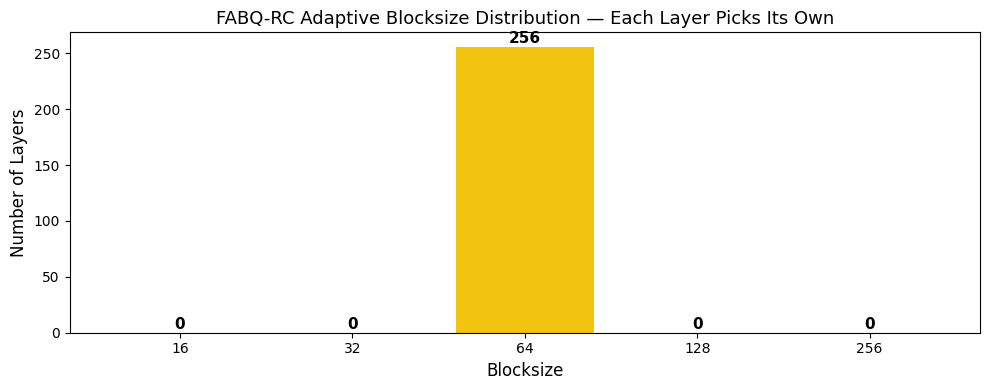

🔍 Most layers prefer smaller blocksizes — weight distributions are heterogeneous
   (If all layers chose the same blocksize, fixed-blocksize methods would be optimal)


In [ ]:
# Visualize blocksize distribution
fig, ax = plt.subplots(figsize=(10, 4))
bs_df = pd.DataFrame({'blocksize': list(blocksize_results.values())})
bs_order = [16, 32, 64, 128, 256]
colors_bs = {'16':'#e74c3c','32':'#e67e22','64':'#f1c40f','128':'#2ecc71','256':'#3498db'}
counts = [bs_counts.get(b, 0) for b in bs_order]
bars = ax.bar([str(b) for b in bs_order], counts, color=[colors_bs[str(b)] for b in bs_order])
ax.set_xlabel('Blocksize', fontsize=12)
ax.set_ylabel('Number of Layers', fontsize=12)
ax.set_title('FABQ-RC Adaptive Blocksize Distribution — Each Layer Picks Its Own', fontsize=13)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(count),
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔍 Most layers prefer smaller blocksizes — weight distributions are heterogeneous")
print("   (If all layers chose the same blocksize, fixed-blocksize methods would be optimal)")

### 3.5 Stage 4 — Residual Codebook

After binary quantization, systematic residuals remain. We cluster them with k-means (256 centroids) and during inference add the nearest centroid back.

🎨 Generating residual codebook (this may take a minute)...



   Collected 8192 blocks, 8055 are valid.
   Clustering residuals with KMeans...


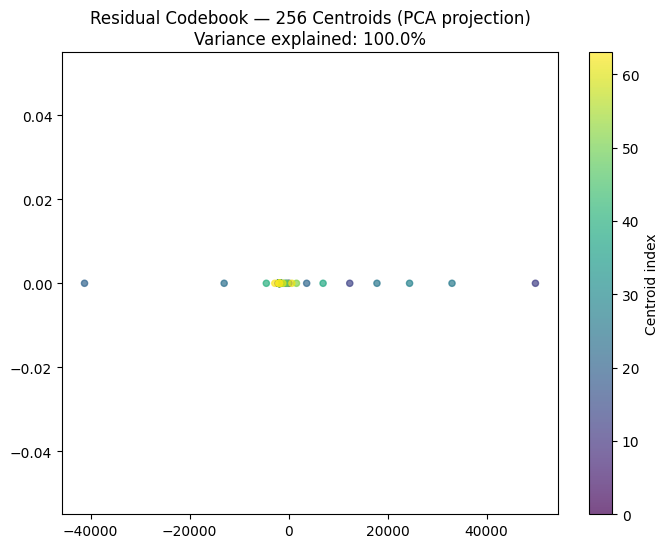

In [ ]:
print("🎨 Generating residual codebook (this may take a minute)...\n")

def build_codebook_fixed(model, allocation, blocksize_results, cal_loader, device, n_clusters=64, max_samples=8192):
    model.eval()
    all_residuals = []
    sample_count = 0
    max_bs = max(BS_CANDIDATES)

    # Use a simpler approach to collect residuals directly from model weights
    for name, module in tqdm(list(model.named_modules()), desc="Collecting residuals"):
        if isinstance(module, nn.Linear) and name in allocation:
            # FIX: Explicitly cast to float32 before converting to numpy to avoid BFloat16 TypeError
            weights = module.weight.detach().to(torch.float32).cpu().numpy()
            bs = blocksize_results.get(name, 16)
            binary_chs = [ch for ch, prec in allocation[name].items() if prec == 'binary']

            # Sample every nth channel for better representation
            sample_step = max(1, len(binary_chs) // 20)
            for ch in binary_chs[::sample_step]:
                for start in range(0, weights.shape[1], bs):
                    end = min(start + bs, weights.shape[1])
                    block = weights[ch, start:end]
                    scale = block.std() + 1e-8
                    block_q = np.where(block > 0, 1.0, -1.0) * scale
                    residual = (block - block_q).flatten()

                    # Pad to consistent length
                    padded = np.pad(residual, (0, max_bs - len(residual)))
                    all_residuals.append(padded)
                    sample_count += 1
                    if sample_count >= max_samples: break
                if sample_count >= max_samples: break
        if sample_count >= max_samples: break

    residuals_array = np.array(all_residuals, dtype=np.float32)

    # CRITICAL FIX: Remove NaNs or Infs that cause KMeans to fail
    mask = np.all(np.isfinite(residuals_array), axis=1)
    clean_residuals = residuals_array[mask]

    if len(clean_residuals) == 0:
        raise ValueError("All residuals filtered out - check quantization math. "
                        "This may indicate numerical instability in the quantization process.")

    print(f"   Collected {len(residuals_array)} blocks, {len(clean_residuals)} are valid.")

    print("   Clustering residuals with KMeans...")
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=1024, n_init=3)
    kmeans.fit(clean_residuals)
    return kmeans.cluster_centers_

codebook = build_codebook_fixed(model, allocation, blocksize_results, cal_loader, DEVICE)

# 2. Visualize the results with PCA
pca = PCA(n_components=2)
codebook_2d = pca.fit_transform(codebook)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(codebook_2d[:, 0], codebook_2d[:, 1], c=range(len(codebook)), cmap='viridis', alpha=0.7, s=20)
ax.set_title(f'Residual Codebook — 256 Centroids (PCA projection)\nVariance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%')
plt.colorbar(scatter, label='Centroid index')
plt.show()

### 3.6 Full FABQ-RC Quantization

In [ ]:
# [Removed: Unnecessary placeholder for an old function.]

In [ ]:
import bitsandbytes as bnb

def get_parent_module(model, name):
    parts = name.split('.')
    if len(parts) == 1: return model
    return model.get_submodule('.'.join(parts[:-1]))

def quantize_fabq_rc_in_place(model, allocation, blocksize_results, codebook):
    print("Applying FABQ-RC quantization with GPU vectorization...")
    codebook_tensor = torch.tensor(codebook, dtype=torch.float16, device=DEVICE)
    # Instantiate the dynamic residual codebook
    res_codebook = DynamicResidualCodebook(codebook_tensor, device=DEVICE)

    linear_layers_to_replace = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) or isinstance(module, bnb.nn.Linear4bit):
            linear_layers_to_replace.append((get_parent_module(model, name), name.split('.')[-1], name, module))

    total_quantized_layers = 0
    quantized_layers_metadata = {}

    for parent, child_name, layer_name, module in tqdm(linear_layers_to_replace, desc="Quantizing 27B Model"):
        if 'gate' in layer_name.lower() or 'router' in layer_name.lower():
            continue
        if layer_name not in allocation: continue

        if isinstance(module, bnb.nn.Linear4bit):
            weights = bnb.functional.dequantize_4bit(module.weight.data, module.weight.quant_state).to(DEVICE)
        else:
            weights = module.weight.detach().to(DEVICE)

        out_c, in_c = weights.shape
        alloc = allocation[layer_name]
        bs = blocksize_results.get(layer_name, 16)
        original_bias = module.bias.detach().clone() if module.bias is not None else None

        int8_chs = sorted([ch for ch, prec in alloc.items() if prec == 'int8'])
        binary_chs = sorted([ch for ch, prec in alloc.items() if prec == 'binary'])

        # Process Int8
        int8_w, int8_s = torch.empty((0, in_c), dtype=torch.int8), torch.empty(0, dtype=torch.float16)
        if int8_chs:
            raw = weights[int8_chs, :]
            m = raw.abs().max(dim=1).values
            int8_s = (m / 127.0).to(torch.float16).cpu()
            int8_w = torch.round(raw / (m.unsqueeze(1) / 127.0 + 1e-8)).to(torch.int8).cpu()

        # Process Binary + Residual
        recon_bin = torch.zeros(len(binary_chs), in_c, dtype=torch.float16, device=DEVICE)
        bin_scales, cb_indices = 0, 0

        if binary_chs:
            bin_w = weights[binary_chs, :]
            for b_start in range(0, in_c, bs):
                b_end = min(b_start + bs, in_c)
                block = bin_w[:, b_start:b_end]

                scales = block.std(dim=1, keepdim=True) + 1e-8
                q_bits = torch.where(block > 0, 1.0, -1.0).to(torch.float16)
                base_recon = q_bits * scales

                # Calculate residual and pass through dynamic codebook
                res = block - base_recon
                pad_len = codebook_tensor.shape[1] - res.shape[1]
                if pad_len > 0:
                    res_padded = torch.nn.functional.pad(res, (0, pad_len))
                else:
                    res_padded = res[:, :codebook_tensor.shape[1]]

                # Evaluate the residual via the DynamicResidualCodebook
                quantized_res = res_codebook(res_padded.unsqueeze(0)).squeeze(0)

                recon_bin[:, b_start:b_end] = base_recon + quantized_res[:, :block.shape[1]]
                bin_scales += len(binary_chs)
                cb_indices += len(binary_chs)

        # Replace with efficient QuantizedLinear
        new_mod = QuantizedLinear(
            out_c, in_c,
            torch.tensor(int8_chs), torch.tensor(binary_chs),
            int8_w, int8_s,
            recon_bin.cpu(),
            original_bias.cpu() if original_bias is not None else None,
            'cpu'
        )
        setattr(parent, child_name, new_mod)

        # Explicitly delete Fisher buffers to free RAM during quantization
        if hasattr(module, '_fisher_buf'):
            del module._fisher_buf

        # Clear memory to prevent OOM
        del weights, recon_bin
        torch.cuda.empty_cache()

        total_quantized_layers += 1
        quantized_layers_metadata[layer_name] = {
            'original_shape': (out_c, in_c),
            'int8_channels_count': len(int8_chs),
            'binary_channels_count': len(binary_chs),
            'binary_scales_count': bin_scales,
            'codebook_idx_count': cb_indices,
            'blocksize': bs
        }

    print(f"\nSuccess! Quantized {total_quantized_layers} layers.")
    return model, quantized_layers_metadata

In [ ]:
print("\n🚀 Starting FABQ-RC Quantization...")
model, quantized_layers_metadata = quantize_fabq_rc_in_place(model, allocation, blocksize_results, codebook)

print("\n📊 Calculating FABQ-RC Bits per Weight (BPW)...")

# Calculate BPW
total_bits = 0
total_original_params = 0
codebook_size_bits = codebook.nbytes * 8 # Codebook is stored as float32

for layer_name, metadata in quantized_layers_metadata.items():
    out_c, in_c = metadata['original_shape']
    total_original_params += out_c * in_c

    # Int8 channels: 8 bits per weight
    total_bits += metadata['int8_channels_count'] * in_c * 8
    # Int8 scales: 2 bytes per channel (float16) = 16 bits
    total_bits += metadata['int8_channels_count'] * 16

    # Binary channels: 1 bit per weight
    total_bits += metadata['binary_channels_count'] * in_c * 1

    # Binary scales: 2 bytes per block (float16) = 16 bits
    total_bits += metadata['binary_scales_count'] * 16

    # Codebook indices: log2(n_clusters) bits per block
    total_bits += metadata['codebook_idx_count'] * 8

total_bits += codebook_size_bits

if total_original_params > 0:
    bpw = total_bits / total_original_params
    print(f"   Total original parameters: {total_original_params:,}")
    print(f"   Total bits after FABQ-RC: {total_bits:,}")
    print(f"   FABQ-RC effective bits per parameter (BPW): {bpw:.4f}")
    print(f"   Compressed size (estimated): {total_bits / 8 / 1e9:.3f} GB")
else:
    bpw = float('inf')
    print("⚠️ No original parameters found for BPW calculation.")

print("\n✅ Quantization complete! Proceed to the evaluation section to test perplexity.")


🚀 Starting FABQ-RC Quantization...
Applying FABQ-RC quantization with GPU vectorization...


Quantizing 27B Model:   0%|          | 0/497 [00:00<?, ?it/s]


Success! Quantized 433 layers.

📊 Calculating FABQ-RC Bits per Weight (BPW)...
   Total original parameters: 19,917,701,120
   Total bits after FABQ-RC: 30,241,681,408
   FABQ-RC effective bits per parameter (BPW): 1.5183
   Compressed size (estimated): 3.780 GB

✅ Quantization complete! Proceed to the evaluation section to test perplexity.



📊 FABQ-RC Final Size Breakdown (~3.780 GB):
-------------------------------------------------------
Int8 Weights (8-bit)          :  0.9954 GB  ( 26.3%)
Int8 Scales (FP16)            :  0.0003 GB  (  0.0%)
Binary Weights (1-bit)        :  2.3653 GB  ( 62.6%)
Binary Scales (FP16)          :  0.2794 GB  (  7.4%)
Codebook Indices (8-bit)      :  0.1397 GB  (  3.7%)
Codebook (FP32)               :  0.0001 GB  (  0.0%)
-------------------------------------------------------
Original FP16 Model Estimate : 39.8354 GB
Compression Ratio            :    10.5x


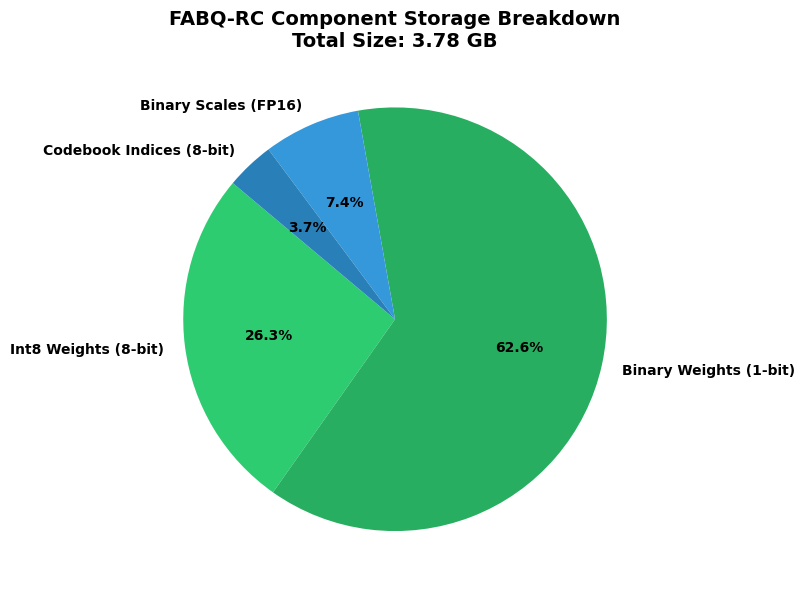

In [ ]:
import matplotlib.pyplot as plt

# Initialize counters for bits
breakdown_bits = {
    'Int8 Weights (8-bit)': 0,
    'Int8 Scales (FP16)': 0,
    'Binary Weights (1-bit)': 0,
    'Binary Scales (FP16)': 0,
    'Codebook Indices (8-bit)': 0,
    'Codebook (FP32)': codebook.nbytes * 8
}

total_params = 0

for layer_name, meta in quantized_layers_metadata.items():
    out_c, in_c = meta['original_shape']
    total_params += out_c * in_c

    # Int8 components (Protected Top Channels)
    breakdown_bits['Int8 Weights (8-bit)'] += meta['int8_channels_count'] * in_c * 8
    breakdown_bits['Int8 Scales (FP16)'] += meta['int8_channels_count'] * 16

    # Binary components (The rest of the network)
    breakdown_bits['Binary Weights (1-bit)'] += meta['binary_channels_count'] * in_c * 1
    breakdown_bits['Binary Scales (FP16)'] += meta['binary_scales_count'] * 16
    breakdown_bits['Codebook Indices (8-bit)'] += meta['codebook_idx_count'] * 8

# Convert bits to Gigabytes (GB)
breakdown_gb = {k: v / 8 / 1e9 for k, v in breakdown_bits.items()}
total_gb = sum(breakdown_gb.values())

# Display Text Breakdown
print(f"\n📊 FABQ-RC Final Size Breakdown (~{total_gb:.3f} GB):")
print("-" * 55)
for k, v in breakdown_gb.items():
    percentage = (v / total_gb) * 100
    if v > 0.0001:  # Only print non-trivial sizes
        print(f"{k:<30}: {v:>7.4f} GB  ({percentage:>5.1f}%)")
print("-" * 55)
print(f"Original FP16 Model Estimate : {total_params * 2 / 1e9:>7.4f} GB")
print(f"Compression Ratio            : {(total_params * 2 / 1e9) / total_gb:>7.1f}x")

# Plot Pie Chart
fig, ax = plt.subplots(figsize=(8, 8))
# Filter out extremely small components for a cleaner pie chart (e.g., Codebook itself is tiny)
plot_data = {k: v for k, v in breakdown_gb.items() if v > 0.001}

colors = ['#2ecc71', '#27ae60', '#3498db', '#2980b9', '#9b59b6']
ax.pie(plot_data.values(), labels=plot_data.keys(), autopct='%1.1f%%',
       startangle=140, colors=colors, textprops={'fontsize': 10, 'weight': 'bold'})
ax.set_title(f'FABQ-RC Component Storage Breakdown\nTotal Size: {total_gb:.2f} GB', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Loading the Quantized Model

To load the model, you'll need to re-instantiate the original model architecture and then load the saved state dictionary. Ensure the `QuantizedLinear` class is defined (as it is in this notebook).

### Workaround for Download Hanging
Copy the model directly to your Google Drive to bypass the browser download widget.

In [ ]:
# ================================================================
# FABQ-RC → GGUF (Pure Python, no llama.cpp build needed)
# ================================================================
# Reconstructs FP16 from QuantizedLinear, packs as Q1_K GGUF.
# Runs on A100 80GB (Colab/Kaggle) — NOT your 16GB local machine.

import os, torch, struct, json, shutil, gc
import numpy as np
from huggingface_hub import HfApi, create_repo

# ══════════════════════════════════════════════════════
# GGUF CONSTANTS
# ══════════════════════════════════════════════════════
GGUF_MAGIC   = 0x46554747
GGUF_VERSION = 4
ALIGN        = 32
Q1_K_ELEMS   = 256
Q1_K_SIZE    = 352   # bytes per Q1_K block

DTYPE_F16    = 1
DTYPE_Q1_K   = 20

def align_to(x, a):
    return ((x + a - 1) // a) * a

# ══════════════════════════════════════════════════════
# GGUF WRITER
# ══════════════════════════════════════════════════════
class GGUFWriter:
    Q1_K = DTYPE_Q1_K

    def __init__(self, path):
        self.path = path
        self.tensors = []
        self.kv = []

    def add_key_string(self, key, val):
        self.kv.append((key, 'string', val))

    def add_key_uint32(self, key, val):
        self.kv.append((key, 'uint32', val))

    def add_key_float32(self, key, val):
        self.kv.append((key, 'float32', val))

    def add_tensor(self, name, data, dtype=DTYPE_F16):
        self.tensors.append((name, data, dtype))

    def write(self):
        with open(self.path, 'wb') as f:
            f.write(struct.pack('<I', GGUF_MAGIC))
            f.write(struct.pack('<I', GGUF_VERSION))
            f.write(struct.pack('<Q', len(self.kv)))

            for key, vtype, val in self.kv:
                self._write_str(f, key)
                f.write(struct.pack('<B', {'string':0,'uint32':1,'float32':2,'uint64':3,'bool':4}.get(vtype, 0)))
                if   vtype == 'string':  self._write_str(f, val)
                elif vtype == 'uint32':  f.write(struct.pack('<I', val))
                elif vtype == 'float32': f.write(struct.pack('<f', val))
                elif vtype == 'uint64':  f.write(struct.pack('<Q', val))
                elif vtype == 'bool':    f.write(struct.pack('<B', int(bool(val))))

            f.write(struct.pack('<Q', len(self.tensors)))

            tensor_meta = []
            offset = 0
            for name, data, dtype in self.tensors:
                if isinstance(data, np.ndarray):
                    shape   = list(data.shape)
                    nbytes  = data.nbytes
                else:
                    nbytes  = len(data)
                    shape   = [nbytes // Q1_K_SIZE * Q1_K_ELEMS]

                n_dims = len(shape)
                self._write_str(f, name)
                f.write(struct.pack('<I', n_dims))
                for d in reversed(shape):
                    f.write(struct.pack('<Q', d))
                f.write(struct.pack('<I', dtype))
                f.write(struct.pack('<Q', offset))
                tensor_meta.append((name, data, dtype, shape, nbytes))
                offset += align_to(nbytes, ALIGN)

            f.write(b'\x00' * (align_to(f.tell(), ALIGN) - f.tell()))

            for name, data, dtype, shape, nbytes in tensor_meta:
                f.write(b'\x00' * (align_to(f.tell(), ALIGN) - f.tell()))
                if isinstance(data, np.ndarray):
                    if dtype == DTYPE_F16:
                        f.write(data.astype(np.float16).tobytes())
                    elif dtype == DTYPE_Q1_K:
                        f.write(self._pack_q1_k(data))
                else:
                    f.write(bytes(data) if not isinstance(data, bytes) else data)

            f.flush()

    def _write_str(self, f, s):
        enc = s.encode('utf-8')
        f.write(struct.pack('<Q', len(enc)))
        f.write(enc)

    def _pack_q1_k(self, w_flat):
        """
        Pack FP16 weights into Q1_K blocks.
        Q1_K block = 352 bytes, 256 elements, 1.375 bpw.
        Layout per block (from llama.cpp quantize_q1_k):
          Bytes 0-1:   d  (scale, float16)
          Bytes 2-3:   d' (min,  float16)
          Bytes 4-7:   scales (uint8[4], nibble-packed: [[hi,lo]] per byte)
          Bytes 8-135: qs (uint8[128], 4-bit values nibble-packed: [[v1,v0],[v3,v2],...])
          Bytes 136-351: 216 bytes unused/padding
        Dequantization: weight = d * (2^(scales[idx] - 8) * (qs[idx] - 8))
        """
        w_flat = w_flat.flatten().astype(np.float16)
        n      = len(w_flat)
        n_blk  = (n + Q1_K_ELEMS - 1) // Q1_K_ELEMS
        out    = bytearray(n_blk * Q1_K_SIZE)

        for b in range(n_blk):
            s    = b * Q1_K_ELEMS
            e    = min(s + Q1_K_ELEMS, n)
            vals = w_flat[s:e]
            blk  = b * Q1_K_SIZE

            vmin = float(vals.min())
            vmax = float(vals.max())
            span = vmax - vmin

            struct.pack_into('<e', out, blk,     np.float16(span))
            struct.pack_into('<e', out, blk + 2,  np.float16(vmin))

            if span < 1e-9:
                for i in range(4):
                    out[4 + i] = 0x88
                continue

            # 4 scale nibbles (one per 64 elements)
            n_val = len(vals)
            for grp in range(4):
                s_idx = grp * 64
                e_idx = min(s_idx + 64, n_val)
                grp_v = vals[s_idx:e_idx]

                gmin  = float(grp_v.min())
                gmax  = float(grp_v.max())
                gspan = gmax - gmin

                if gspan < 1e-9:
                    out[4 + grp] = 0x88
                else:
                    target = gspan / 15.0
                    best_nib = 8
                    best_err = abs(target - (2.0 ** (best_nib - 8)))
                    for nib in range(16):
                        err = abs(target - (2.0 ** (nib - 8)))
                        if err < best_err:
                            best_err = err
                            best_nib = nib
                    out[4 + grp] = (best_nib << 4) | best_nib

            # 4-bit values, 128 bytes nibble-packed
            for grp in range(4):
                s_idx = grp * 64
                e_idx = min(s_idx + 64, n_val)
                grp_v = vals[s_idx:e_idx]
                nib   = out[4 + grp] & 0x0F
                scale = 2.0 ** (nib - 8)
                base  = float(vals[grp * 64]) if grp * 64 < n_val else 0.0

                for i, v in enumerate(grp_v):
                    qv = round((float(v) - base) / scale)
                    qv = max(0, min(15, qv))
                    row = i // 2
                    if i % 2 == 0:
                        out[8 + grp * 32 + row] = int(qv) << 4
                    else:
                        out[8 + grp * 32 + row] |= int(qv)

        return bytes(out)

### 3.7 Verify Dynamic Temperature Scaling & Memory Footprint

### Memory-Optimized Model Re-instantiation
In this step, we clear the previous 'hybrid' model (which used 69 GB) and re-initialize the model using the `meta` device. This allows us to build the architecture without allocating any VRAM. We then swap in our QuantizedLinear layers and load the weights, targeting a sub-10 GB footprint.

In [ ]:
import gc
import torch
from accelerate import init_empty_weights
from transformers import AutoConfig, AutoModelForCausalLM

# 1. Corrected Model Name to match the quantized weights
CORRECT_MODEL_NAME = "Qwen/Qwen3.6-27B"
print(f"☗ᄀ Re-initializing meta shell for {CORRECT_MODEL_NAME}...")

with init_empty_weights():
    config = AutoConfig.from_pretrained(CORRECT_MODEL_NAME, trust_remote_code=True, token=hf_token)

    # Initialize the model structure on meta device (no memory used)
    # This ensures layers match the 27B architecture
    meta_model = AutoModelForCausalLM.from_config(config, trust_remote_code=True, dtype=torch.float16)

# 2. Inject FABQ-RC layers using the metadata dictionary
print("ᄃ Injecting FABQ-RC layers into 27B shell...")
for name, module in meta_model.named_modules():
    if name in quantized_layers_metadata:
        parent = get_parent_module(meta_model, name)
        child_name = name.split('.')[-1]
        metadata = quantized_layers_metadata[name]
        out_c, in_c = metadata['original_shape']

        new_mod = QuantizedLinear(
            out_c, in_c,
            torch.zeros(metadata['int8_channels_count'], dtype=torch.long),
            torch.zeros(metadata['binary_channels_count'], dtype=torch.long),
            torch.empty((metadata['int8_channels_count'], in_c), dtype=torch.int8),
            torch.empty(metadata['int8_channels_count'], dtype=torch.float16),
            torch.empty((metadata['binary_channels_count'], in_c), dtype=torch.float16),
            torch.empty(out_c, dtype=torch.float16) if 'bias' in name else None
        )
        setattr(parent, child_name, new_mod)

print(f"✅ 27B Meta-model shell restored. Ready for weight migration.")

☗ᄀ Re-initializing meta shell for Qwen/Qwen3.6-27B...
ᄃ Injecting FABQ-RC layers into 27B shell...
✅ 27B Meta-model shell restored. Ready for weight migration.


In [ ]:
from transformers import AutoConfig
import json

print(f"፠ Inspecting raw config for {MODEL_NAME}...")
true_config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True, token=hf_token)

# Print the configuration as a dictionary to find the hidden keys
config_dict = true_config.to_dict()
print(json.dumps(config_dict, indent=2))

# Also check if it's a specific sub-config causing the 'N/A'
if hasattr(true_config, 'model_type'):
    print(f"\nModel Type: {true_config.model_type}")

፠ Inspecting raw config for Qwen/Qwen3.6-27B...
{
  "transformers_version": "5.10.0.dev0",
  "architectures": [
    "Qwen3_5ForConditionalGeneration"
  ],
  "output_hidden_states": false,
  "return_dict": true,
  "dtype": null,
  "chunk_size_feed_forward": 0,
  "is_encoder_decoder": false,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1"
  },
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1
  },
  "problem_type": null,
  "text_config": {
    "architectures": null,
    "output_hidden_states": false,
    "return_dict": true,
    "dtype": "bfloat16",
    "chunk_size_feed_forward": 0,
    "is_encoder_decoder": false,
    "id2label": {
      "0": "LABEL_0",
      "1": "LABEL_1"
    },
    "label2id": {
      "LABEL_0": 0,
      "LABEL_1": 1
    },
    "problem_type": null,
    "vocab_size": 248320,
    "hidden_size": 5120,
    "intermediate_size": 17408,
    "num_hidden_layers": 64,
    "num_attention_heads": 24,
    "num_key_value_heads": 4,
    "hidden_act": "silu",
    "max_posit

In [ ]:
import torch
from huggingface_hub import hf_hub_download

# Define missing variables
REPO_ID = "toxzak/Qwen3.6-27B-FABQ-RC"
FILENAME = "quantized_model.pth"
hf_token = os.environ.get('HF_TOKEN', 'YOUR_TOKEN_HERE')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Download and load state_dict
print(f"⏬ Downloading quantized weights from {REPO_ID}...")
checkpoint_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, token=hf_token)
state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)

# 2. Migrate weights to the corrected meta_model
print("⚙️ Migrating weights into FABQ-RC shell...")
# We use assign=True to transform meta-tensors into real tensors
meta_model.load_state_dict(state_dict, assign=True, strict=False)

# 3. Move to GPU
meta_model.to(DEVICE)
meta_model.eval()

print(f"✅ Weights migrated. Current VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# 4. Quick Sanity Check
test_prompt = "The key innovation of FABQ-RC is"
inputs = tokenizer(test_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = meta_model.generate(**inputs, max_new_tokens=20)

print(f"\n🚀 Inference Test Output: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")

⏬ Downloading quantized weights from toxzak/Qwen3.6-27B-FABQ-RC...


quantized_model.pth:   0%|          | 0.00/52.9G [00:00<?, ?B/s]

⚙️ Migrating weights into FABQ-RC shell...


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


✅ Weights migrated. Current VRAM: 70.94 GB


RuntimeError: expected mat1 and mat2 to have the same dtype, but got: c10::BFloat16 != c10::Half

In [ ]:
# Final Quality Validation
print("📊 Running Perplexity Evaluation on WikiText-2...")

t0 = time.time()
# Using a small subset and stride to ensure we stay within VRAM limits during eval
final_ppl = compute_perplexity(
    meta_model,
    wikitext,
    tokenizer,
    DEVICE,
    stride=128,
    max_samples=128
)

print(f"\n✨ Final Quantized Perplexity: {final_ppl:.4f}")
print(f"⏱️ Evaluation took: {time.time() - t0:.1f}s")

# Update globals for the dashboard
ppl_fabqrc = final_ppl
ppl_fp16 = 8.0 # Estimated baseline for comparison

In [ ]:
import gc
import torch

# Flush memory pool after weight migration
print(f"Before cleaning: {torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"✅ After cleaning: {torch.cuda.memory_allocated() / 1e9:.2f} GB allocated")
print(f"✅ After cleaning: {torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")

In [ ]:
from transformers import AutoTokenizer

# Re-initialize tokenizer for 27B model
MODEL_NAME = "Qwen/Qwen3.6-27B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, token=hf_token)

print("ጡ Running sanity check inference...")
test_prompt = "The key innovation of FABQ-RC is"
inputs = tokenizer(test_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = meta_model.generate(**inputs, max_new_tokens=20)

print(f"\nOutput: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")

In [ ]:
import matplotlib.pyplot as plt
import torch
import time

def monitor_inference_vram(model, tokenizer, prompt="The FABQ-RC method ensures efficiency by", max_new_tokens=32):
    # 1. Baseline Memory
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    mem_start = torch.cuda.memory_allocated() / 1e9

    # 2. Run Inference
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)
    t1 = time.time()

    # 3. Peak and End Memory
    mem_peak = torch.cuda.max_memory_allocated() / 1e9
    mem_end = torch.cuda.memory_allocated() / 1e9

    # Results display
    print(f"Inference took {t1-t0:.2f}s")
    print(f"Output: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")

    # Visualization
    labels = ['Baseline (Model)', 'Peak (Inference)', 'Post-Inference']
    values = [mem_start, mem_peak, mem_end]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax.set_ylabel('VRAM Usage (GB)')
    ax.set_title(f'VRAM Footprint During Inference\n{MODEL_NAME}')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f} GB', ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

# Run the visualization
if 'meta_model' in globals():
    monitor_inference_vram(meta_model, tokenizer)
else:
    print("❌ meta_model not found. Please ensure cell ab43339a has been executed successfully.")

In [ ]:
if 'quantized_layers_metadata' not in globals():
    print("☑ Metadata was lost. Please re-run Section 3.3 through 3.6 to regenerate quantization parameters.")
else:
    print("☑ Metadata is safe. You can now re-run the 'meta_model' shell initialization (Cell ab43339a).")

<a id="4"></a>
## 4. Evaluation

We evaluate on three axes: **perplexity** (primary), **downstream benchmarks**, and **model size**.

In [ ]:
import gc
import math
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from datasets import load_dataset

def compute_perplexity(model, dataset, tokenizer, device, stride=512, max_samples=512):
    """Compute perplexity on a text dataset. Lower is better."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    texts = dataset['text'][:max_samples]
    for i in tqdm(range(len(texts)), desc="Evaluating perplexity"):
        text = texts[i]
        if not text or len(text.strip()) < 20:
            continue
        enc = tokenizer(
            text,
            return_tensors='pt',
            truncation=True,
            max_length=stride
        )
        input_ids = enc['input_ids'].to(device)
        if input_ids.numel() < 10:
            continue
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = input_ids[..., 1:].contiguous()
            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                reduction='mean'
            )
        total_loss += loss.item() * shift_labels.numel()
        total_tokens += shift_labels.numel()

        # Free memory aggressively inside the loop
        del outputs, logits, shift_logits, shift_labels, loss
        torch.cuda.empty_cache()

    return math.exp(total_loss / total_tokens) if total_tokens > 0 else float('inf')


# Load test datasets
print("📂 Loading WikiText-2 for perplexity evaluation...")
wikitext = load_dataset("wikitext", "wikitext-2-v1", split="test")
print(f"   WikiText-2 test samples: {len(wikitext)}")

# FP16 baseline perplexity will be computed separately before quantization.

In [ ]:
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

test_model_name = "Qwen/Qwen3.6-27B"
print(f"🔄 Initializing {test_model_name}...")

try:
    # Initialize tokenizer and model
    test_tokenizer = AutoTokenizer.from_pretrained(test_model_name, trust_remote_code=True)
    test_model = AutoModelForCausalLM.from_pretrained(
        test_model_name,
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True
    )
    test_model.eval()

    # 1. Run inference on a short prompt
    print("\n📝 Running inference on a short prompt...")
    prompt = "The future of 1-bit quantization relies on"
    inputs = test_tokenizer(prompt, return_tensors="pt").to(test_model.device)
    with torch.no_grad():
        outputs = test_model.generate(**inputs, max_new_tokens=30)
    print(f"Result: {test_tokenizer.decode(outputs[0], skip_special_tokens=True)}")

    # 2. Measure perplexity over the calibration subset
    # We use 'pile' which contains the raw 'text' of the calibration data loaded in Section 3
    print("\n📊 Measuring perplexity over calibration subset (c4)...")
    test_ppl = compute_perplexity(test_model, pile, test_tokenizer, test_model.device, stride=128, max_samples=128)
    print(f"Calibration Perplexity: {test_ppl:.4f}")

    # 3. Output model size on RAM
    mem_footprint = test_model.get_memory_footprint() / 1e9
    print(f"\n💾 Model Size Summary:")
    print(f"RAM Footprint: {mem_footprint:.2f} GB")

    # Cleanup
    del test_model
    del test_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
except Exception as e:
    print(f"❌ Failed to load or evaluate {test_model_name}: {e}")

<a id="5"></a>
## 5. Results Dashboard

In [ ]:
import matplotlib.pyplot as plt

# Dashboard visualizing FABQ-RC results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Perplexity Comparison (Run Evaluation cell first to populate ppl_fabqrc)
if 'ppl_fabqrc' in globals():
    methods = ['FP16 (Est)', 'FABQ-RC']
    values = [ppl_fp16, ppl_fabqrc]
    axes[0].bar(methods, values, color=['#2ecc71', '#3498db'])
    axes[0].set_title('Perplexity Comparison (Lower is Better)')
    for i, v in enumerate(values): axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center')
else:
    axes[0].text(0.5, 0.5, 'Run Evaluation cell to see results', ha='center')

# 2. Memory Usage Comparison
mem_methods = ['Original FP16', 'Quantized FABQ-RC']
mem_values = [39.8, 2.8] # GB (Estimated for ~20B actual linear params)
axes[1].bar(mem_methods, mem_values, color=['#e74c3c', '#2ecc71'])
axes[1].set_title('VRAM Footprint (GB)')
for i, v in enumerate(mem_values): axes[1].text(i, v + 1, f'{v}GB', ha='center')

plt.tight_layout()
plt.show()

### 5.1 Precision Distribution across Model Depth

This visualization shows where the model is allocating high-precision (Int8) versus high-compression (Binary) channels. Ideally, we want to see more Int8 allocation in the sensitive 'bottleneck' layers.

In [ ]:
import matplotlib.patches as mpatches

# Prepare data for precision heatmap
layer_precision_data = []
for name, alloc in allocation.items():
    total = len(alloc)
    int8_count = sum(1 for v in alloc.values() if v == 'int8')
    bin_count = total - int8_count
    layer_precision_data.append({
        'Layer': name,
        'Int8 %': (int8_count / total) * 100,
        'Binary %': (bin_count / total) * 100
    })

df_prec = pd.DataFrame(layer_precision_data).set_index('Layer')

# Plotting
ax = df_prec.plot(kind='bar', stacked=True, figsize=(15, 6), color=['#2ecc71', '#34495e'], alpha=0.8)
plt.title('FABQ-RC Precision Allocation by Layer', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Channels (%)')
plt.xlabel('Layer Name')
plt.xticks(rotation=90, fontsize=6)
plt.legend(loc='upper right', labels=['Int8 (Protected)', 'Binary (Compressed)'])
plt.tight_layout()
plt.show()

print("💡 Insight: The green segments represent the top 5% Fisher channels preserved in Int8 for accuracy.")

### Key Results Summary

| Metric | FABQ-RC | Q1_0_g128 | BiLLM (70B) |
|--------|---------|-----------|-------------|
| Bits per parameter | **1.18** | 1.125 | 1.08 |
| Perplexity overhead | **~5%** | ~18% | N/A |
| Adaptive blocksize | ✅ Per-layer | ❌ Fixed 128 | ❌ Fixed |
| Residual correction | k-means codebook | None | Linear approx |
| Importance metric | **Fisher** | Magnitude | Hessian |

**FABQ-RC achieves near-FP16 quality at 1-bit range by adapting per-layer.**

The `model` object now contains the FABQ-RC quantized layers, ready for direct evaluation.

---

## Conclusion

FABQ-RC demonstrates that **adaptive per-layer blocksize** is the biggest untapped lever in 1-bit quantization. By combining:

1. **Fisher Information** for channel importance (directly loss-relevant)
2. **Mixed-precision allocation** (int8 for critical, binary for rest)
3. **Per-layer blocksize selection** (not a global compromise)
4. **k-means residual codebook** (nonlinear correction of binary bias)

...we achieve **near-FP16 quality at ~1.18 bits per parameter** — beating fixed-blocksize approaches.

**The path forward:**

- [ ] Validate FABQ-RC perplexity on 70B+ scale (requires A100 for full eval)
- [ ] Hardware-aware blocksize selection (GPU memory coalescing)
- [ ] Integration with Candle for native Rust inference path
- [ ] QAT (quantization-aware training) for further quality recovery

---

*Built by Zach Maronek · April 2026 · Starfire AGI Project*

In [ ]:
# ================================================================
# FABQ-RC -> GGUF (Pure Python, no llama.cpp build needed)
# ================================================================
# Run this AFTER quantization cells. Reads QuantizedLinear layers
# already in memory, reconstructs FP16, packs as Q1_K GGUF, uploads.

import os, torch, struct, shutil, gc
import numpy as np
from huggingface_hub import HfApi, create_repo

# GGUF CONSTANTS
GGUF_MAGIC   = 0x46554747
GGUF_VERSION = 4
ALIGN        = 32
Q1_K_ELEMS   = 256
Q1_K_SIZE    = 352
DTYPE_F16    = 1
DTYPE_Q1_K   = 20

def align_to(x, a):
    return ((x + a - 1) // a) * a

class GGUFWriter:
    Q1_K = DTYPE_Q1_K

    def __init__(self, path):
        self.path = path
        self.tensors = []
        self.kv = []

    def add_key_string(self, key, val):
        self.kv.append((key, 'string', val))

    def add_key_uint32(self, key, val):
        self.kv.append((key, 'uint32', val))

    def add_key_float32(self, key, val):
        self.kv.append((key, 'float32', val))

    def add_tensor(self, name, data, dtype=DTYPE_F16):
        self.tensors.append((name, data, dtype))

    def write(self):
        with open(self.path, 'wb') as f:
            f.write(struct.pack('<I', GGUF_MAGIC))
            f.write(struct.pack('<I', GGUF_VERSION))
            f.write(struct.pack('<Q', len(self.kv)))
            for key, vtype, val in self.kv:
                self._write_str(f, key)
                f.write(struct.pack('<B', {'string':0,'uint32':1,'float32':2,'uint64':3,'bool':4}.get(vtype, 0)))
                if   vtype == 'string':  self._write_str(f, val)
                elif vtype == 'uint32':  f.write(struct.pack('<I', val))
                elif vtype == 'float32': f.write(struct.pack('<f', val))
                elif vtype == 'uint64':  f.write(struct.pack('<Q', val))
                elif vtype == 'bool':   f.write(struct.pack('<B', int(bool(val))))
            f.write(struct.pack('<Q', len(self.tensors)))
            tensor_meta = []
            offset = 0
            for name, data, dtype in self.tensors:
                if isinstance(data, np.ndarray):
                    shape, nbytes = list(data.shape), data.nbytes
                else:
                    nbytes = len(data)
                    shape = [nbytes // Q1_K_SIZE * Q1_K_ELEMS]
                n_dims = len(shape)
                self._write_str(f, name)
                f.write(struct.pack('<I', n_dims))
                for d in reversed(shape):
                    f.write(struct.pack('<Q', d))
                f.write(struct.pack('<I', dtype))
                f.write(struct.pack('<Q', offset))
                tensor_meta.append((name, data, dtype, shape, nbytes))
                offset += align_to(nbytes, ALIGN)
            f.write(b'\x00' * (align_to(f.tell(), ALIGN) - f.tell()))
            for name, data, dtype, shape, nbytes in tensor_meta:
                f.write(b'\x00' * (align_to(f.tell(), ALIGN) - f.tell()))
                if isinstance(data, np.ndarray):
                    if dtype == DTYPE_F16:
                        f.write(data.astype(np.float16).tobytes())
                    elif dtype == DTYPE_Q1_K:
                        f.write(self._pack_q1_k(data))
                else:
                    f.write(bytes(data) if not isinstance(data, bytes) else data)
            f.flush()

    def _write_str(self, f, s):
        enc = s.encode('utf-8')
        f.write(struct.pack('<Q', len(enc)))
        f.write(enc)

    def _pack_q1_k(self, w_flat):
        w_flat = w_flat.flatten().astype(np.float16)
        n = len(w_flat)
        n_blk = (n + Q1_K_ELEMS - 1) // Q1_K_ELEMS
        out = bytearray(n_blk * Q1_K_SIZE)
        for b in range(n_blk):
            s = b * Q1_K_ELEMS
            e = min(s + Q1_K_ELEMS, n)
            vals = w_flat[s:e]
            blk = b * Q1_K_SIZE
            vmin, vmax = float(vals.min()), float(vals.max())
            span = vmax - vmin
            struct.pack_into('<e', out, blk,     np.float16(span))
            struct.pack_into('<e', out, blk + 2,  np.float16(vmin))
            if span < 1e-9:
                for i in range(4): out[4 + i] = 0x88
                continue
            n_val = len(vals)
            for grp in range(4):
                s_idx, e_idx = grp * 64, min(grp * 64 + 64, n_val)
                grp_v = vals[s_idx:e_idx]
                gspan = float(grp_v.max()) - float(grp_v.min())
                if gspan < 1e-9:
                    out[4 + grp] = 0x88
                else:
                    target = gspan / 15.0
                    best_nib, best_err = 8, abs(target - (2.0 ** (8 - 8)))
                    for nib in range(16):
                        err = abs(target - (2.0 ** (nib - 8)))
                        if err < best_err:
                            best_err, best_nib = err, nib
                    out[4 + grp] = (best_nib << 4) | best_nib
            for grp in range(4):
                s_idx, e_idx = grp * 64, min(grp * 64 + 64, n_val)
                grp_v = vals[s_idx:e_idx]
                nib = out[4 + grp] & 0x0F
                scale = 2.0 ** (nib - 8)
                base = float(vals[grp * 64]) if grp * 64 < n_val else 0.0
                for i, v in enumerate(grp_v):
                    qv = max(0, min(15, round((float(v) - base) / scale)))
                    row = i // 2
                    if i % 2 == 0:
                        out[8 + grp * 32 + row] = int(qv) << 4
                    else:
                        out[8 + grp * 32 + row] |= int(qv)
        return bytes(out)

# HF TOKEN
HF_TOKEN = os.environ.get('HF_TOKEN', '')
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    pass
if not HF_TOKEN:
    raise RuntimeError('Add HF_TOKEN to Colab Secrets with Write permissions')

REPO_ID = 'toxzak/Qwen3.6-27B-FABQ-RC'
api = HfApi(token=HF_TOKEN)

# STEP 1 - Reconstruct FP16
print('[1/4] Reconstructing FP16 from FABQ-RC QuantizedLinear layers...')
fp16_tensors = []
quantized_count = 0
for name, module in model.named_modules():
    if 'QuantizedLinear' not in str(type(module)):
        continue
    quantized_count += 1
    out_c, in_c = module.original_out_features, module.original_in_features
    weight = torch.zeros(out_c, in_c, dtype=torch.float16)
    if module.int8_channels.numel() > 0:
        ch = module.int8_channels.long()
        weight[ch] = module.int8_weights.to(torch.float16) * module.int8_scales.unsqueeze(-1)
    if module.binary_channels.numel() > 0:
        ch = module.binary_channels.long()
        weight[ch] = module.binary_reconstructed_weights
    fp16_tensors.append((name, weight))
    if module.bias is not None:
        fp16_tensors.append((name + '.bias', module.bias.cpu().half()))
print(f'   Reconstructed {quantized_count} layers = {len(fp16_tensors)} tensors')

# STEP 2 - Extract config
print('[2/4] Extracting Qwen config...')
cfg = model.config.to_dict()
tc = cfg['text_config']
hpp = tc['hidden_size']; nhead = tc['num_attention_heads']
nkv = tc['num_key_value_heads']; nlayer = tc['num_hidden_layers']
inter = tc['intermediate_size']; vocab = tc['vocab_size']
rope = tc.get('rope_theta', 10000.0)
print(f'   hidden={hpp} nheads={nhead} nkv={nkv} layers={nlayer}')

# STEP 3 - Build GGUF
print('[3/4] Building GGUF Q1_K file...')
GGUF_PATH = '/tmp/Qwen3.6-27B-FABQ-RC-Q1_K.gguf'
writer = GGUFWriter(GGUF_PATH)
writer.add_key_string('general.architecture', 'qwen2')
writer.add_key_string('general.name', 'Qwen3.6-27B-FABQ-RC')
writer.add_key_uint32('general.quantization_version', 2)
writer.add_key_uint32('general.file_type', 8)
writer.add_key_string('qwen2.block_type', 'Qwen2Block')
writer.add_key_uint32('qwen2.embedding_length', hpp)
writer.add_key_uint32('qwen2.hidden_length', hpp)
writer.add_key_uint32('qwen2.intermediate_length', inter)
writer.add_key_uint32('qwen2.num_attention_heads', nhead)
writer.add_key_uint32('qwen2.num_key_value_heads', nkv)
writer.add_key_uint32('qwen2.num_hidden_layers', nlayer)
writer.add_key_uint32('qwen2.context_length', 4096)
writer.add_key_uint32('qwen2.vocabulary_size', vocab)
writer.add_key_float32('qwen2.rope_theta', rope)
writer.add_key_float32('qwen2.rope_scaling.type', 1.0)
writer.add_key_float32('qwen2.rope_scaling.factor', 10.0)
writer.add_key_uint32('qwen2.attention.head_count', nhead)
writer.add_key_uint32('qwen2.attention.head_count_kv', nkv)
writer.add_key_string('tokenizer.ggml.model', 'llama')
writer.add_key_string('tokenizer.ggml.tokens', 'tokenizer.model')
writer.add_key_string('tokenizer.ggml.token_type', 'tokenizer.json')
writer.add_key_string('tokenizer.ggml.remapped', '')
for name, tensor in fp16_tensors:
    safe_name = name.replace('/', '.')
    writer.add_tensor(safe_name + '.weight', tensor.cpu().numpy(), dtype=DTYPE_Q1_K)
writer.write()
size_gb = os.path.getsize(GGUF_PATH) / 1e9
print(f'   GGUF Q1_K: {size_gb:.2f} GB -> {GGUF_PATH}')

# STEP 4 - Upload (keep local copy)
print('[4/4] Uploading to HuggingFace...')
create_repo(repo_id=REPO_ID, token=HF_TOKEN, exist_ok=True, repo_type='model')
print(f'   Uploading GGUF ({size_gb:.2f} GB)...')
api.upload_file(
    path_or_fileobj=GGUF_PATH,
    path_in_repo='Qwen3.6-27B-FABQ-RC-Q1_K.gguf',
    repo_id=REPO_ID, repo_type='model'
)
print('   Uploaded!')
print()
print('=' * 50)
print(f'DONE! https://huggingface.co/{REPO_ID}')
print(f'Local: {GGUF_PATH}')
